0
Features Shape: (70000, 25)
Target Shape: (70000,)
Categorical Columns:

['Customer_Region', 'Product_Category', 'Brand', 'Payment_Method', 'Festival_Season', 'Source_City', 'Destination_City', 'Courier_Partner']

Numerical Columns:

['Customer_Tenure_Days', 'Total_Orders', 'Previous_RTO_Count', 'Previous_Return_Count', 'Previous_COD_Orders', 'Previous_COD_Refusals', 'First_Time_Customer', 'Seller_Rating', 'Seller_RTO_Rate', 'Average_Dispatch_Time', 'Seller_Cancellation_Rate', 'Order_Value', 'Discount_Percentage', 'Quantity', 'Destination_PIN', 'Estimated_Delivery_Days', 'Logistics_Cost']
Number of Numerical Features: 17
Number of Categorical Features: 8
Customer_Region: 6 unique values
Product_Category: 12 unique values
Brand: 15 unique values
Payment_Method: 2 unique values
Festival_Season: 2 unique values
Source_City: 6 unique values
Destination_City: 28 unique values
Courier_Partner: 7 unique values
(70000, 61)
Training Features : (56000, 61)
Testing Features  : (14000, 61)
Train

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 1]


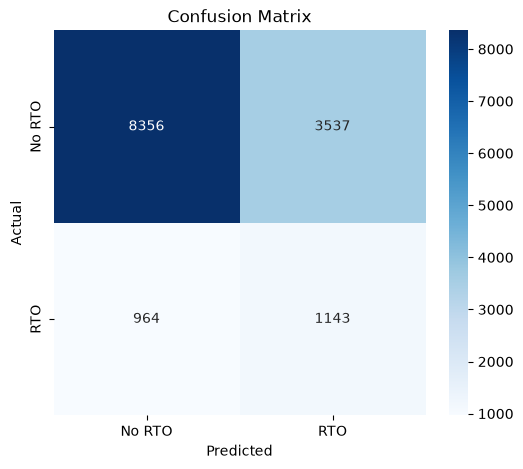

              precision    recall  f1-score   support

           0       0.90      0.70      0.79     11893
           1       0.24      0.54      0.34      2107

    accuracy                           0.68     14000
   macro avg       0.57      0.62      0.56     14000
weighted avg       0.80      0.68      0.72     14000

ROC AUC Score: 0.6801134870088859


Negative: 47570
Positive: 8430
Scale Pos Weight: 5.6429418742586
              precision    recall  f1-score   support

           0       0.90      0.70      0.79     11893
           1       0.24      0.54      0.34      2107

    accuracy                           0.68     14000
   macro avg       0.57      0.62      0.56     14000
weighted avg       0.80      0.68      0.72     14000

0.6801134870088859


In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("../data/Meesho_RTO_Prevention_Dataset.csv")
df.head()
df.isnull().sum()
print(df.duplicated().sum())
df["RTO"] = df["RTO"].map({
    "Yes": 1,
    "No": 0
})

df["RTO"].value_counts()
df = df.drop(columns=[
    "Order_ID",
    "Customer_ID",
    "Seller_ID"
])

df.head()
X = df.drop("RTO", axis=1)
y = df["RTO"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:\n")
print(categorical_cols)

print("\nNumerical Columns:\n")
print(numerical_cols)
print("Number of Numerical Features:", len(numerical_cols))

print("Number of Categorical Features:", len(categorical_cols))
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")
    # Columns to One-Hot Encode
one_hot_cols = [
    "Customer_Region",
    "Product_Category",
    "Brand",
    "Payment_Method",
    "Festival_Season",
    "Source_City",
    "Courier_Partner"
]

X = pd.get_dummies(
    X,
    columns=one_hot_cols,
    drop_first=True
)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["Destination_City"] = le.fit_transform(X["Destination_City"])
print(X.shape)

X.head()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)
# Check class distribution
print(y_train.value_counts())

print("\nPercentage:\n")

print(y_train.value_counts(normalize=True) * 100)
import plotly.express as px

fig = px.pie(
    names=["No RTO", "RTO"],
    values=y_train.value_counts().sort_index(),
    title="Training Dataset Class Distribution"
)

fig.show()
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,

    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred[:20])
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No RTO", "RTO"],
    yticklabels=["No RTO", "RTO"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc)
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)
import plotly.express as px

fig = px.bar(
    feature_importance.head(10),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 10 Most Important Features"
)

fig.show()
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("Scale Pos Weight:", scale_pos_weight)
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_prob))



In [27]:
type(model)

xgboost.sklearn.XGBClassifier

In [31]:
import joblib

joblib.dump(model, "../models/rto_xgboost_model.pkl")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [35]:
loaded_model = joblib.load("../models/rto_xgboost_model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [38]:
print(X_train.columns.tolist())

['Customer_Tenure_Days', 'Total_Orders', 'Previous_RTO_Count', 'Previous_Return_Count', 'Previous_COD_Orders', 'Previous_COD_Refusals', 'First_Time_Customer', 'Seller_Rating', 'Seller_RTO_Rate', 'Average_Dispatch_Time', 'Seller_Cancellation_Rate', 'Order_Value', 'Discount_Percentage', 'Quantity', 'Destination_City', 'Destination_PIN', 'Estimated_Delivery_Days', 'Logistics_Cost', 'Customer_Region_East', 'Customer_Region_North', 'Customer_Region_Northeast', 'Customer_Region_South', 'Customer_Region_West', 'Product_Category_Beauty & Personal Care', 'Product_Category_Bedsheets & Furnishings', 'Product_Category_Footwear', 'Product_Category_Home Decor', 'Product_Category_Jewellery & Accessories', 'Product_Category_Kids Wear', 'Product_Category_Kitchen & Home', "Product_Category_Men's T-Shirts", 'Product_Category_Mobile Accessories', 'Product_Category_Sarees', 'Product_Category_Women Ethnic Wear', 'Brand_Comfy Nights', 'Brand_Fabrino', 'Brand_GlowNest', 'Brand_Kalakriti', 'Brand_Localoom', 'B

In [42]:
print(X_train.columns.tolist())

['Customer_Tenure_Days', 'Total_Orders', 'Previous_RTO_Count', 'Previous_Return_Count', 'Previous_COD_Orders', 'Previous_COD_Refusals', 'First_Time_Customer', 'Seller_Rating', 'Seller_RTO_Rate', 'Average_Dispatch_Time', 'Seller_Cancellation_Rate', 'Order_Value', 'Discount_Percentage', 'Quantity', 'Destination_City', 'Destination_PIN', 'Estimated_Delivery_Days', 'Logistics_Cost', 'Customer_Region_East', 'Customer_Region_North', 'Customer_Region_Northeast', 'Customer_Region_South', 'Customer_Region_West', 'Product_Category_Beauty & Personal Care', 'Product_Category_Bedsheets & Furnishings', 'Product_Category_Footwear', 'Product_Category_Home Decor', 'Product_Category_Jewellery & Accessories', 'Product_Category_Kids Wear', 'Product_Category_Kitchen & Home', "Product_Category_Men's T-Shirts", 'Product_Category_Mobile Accessories', 'Product_Category_Sarees', 'Product_Category_Women Ethnic Wear', 'Brand_Comfy Nights', 'Brand_Fabrino', 'Brand_GlowNest', 'Brand_Kalakriti', 'Brand_Localoom', 'B

In [46]:
print(X_train.columns.tolist())

['Customer_Tenure_Days', 'Total_Orders', 'Previous_RTO_Count', 'Previous_Return_Count', 'Previous_COD_Orders', 'Previous_COD_Refusals', 'First_Time_Customer', 'Seller_Rating', 'Seller_RTO_Rate', 'Average_Dispatch_Time', 'Seller_Cancellation_Rate', 'Order_Value', 'Discount_Percentage', 'Quantity', 'Destination_City', 'Destination_PIN', 'Estimated_Delivery_Days', 'Logistics_Cost', 'Customer_Region_East', 'Customer_Region_North', 'Customer_Region_Northeast', 'Customer_Region_South', 'Customer_Region_West', 'Product_Category_Beauty & Personal Care', 'Product_Category_Bedsheets & Furnishings', 'Product_Category_Footwear', 'Product_Category_Home Decor', 'Product_Category_Jewellery & Accessories', 'Product_Category_Kids Wear', 'Product_Category_Kitchen & Home', "Product_Category_Men's T-Shirts", 'Product_Category_Mobile Accessories', 'Product_Category_Sarees', 'Product_Category_Women Ethnic Wear', 'Brand_Comfy Nights', 'Brand_Fabrino', 'Brand_GlowNest', 'Brand_Kalakriti', 'Brand_Localoom', 'B

In [50]:
import joblib

joblib.dump(X_train.columns.tolist(), "../models/feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [51]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("Scale Pos Weight:", scale_pos_weight)


Negative: 47570
Positive: 8430
Scale Pos Weight: 5.6429418742586


In [52]:
import joblib

joblib.dump(model, "../models/test_model.pkl")

loaded_model = joblib.load("../models/test_model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


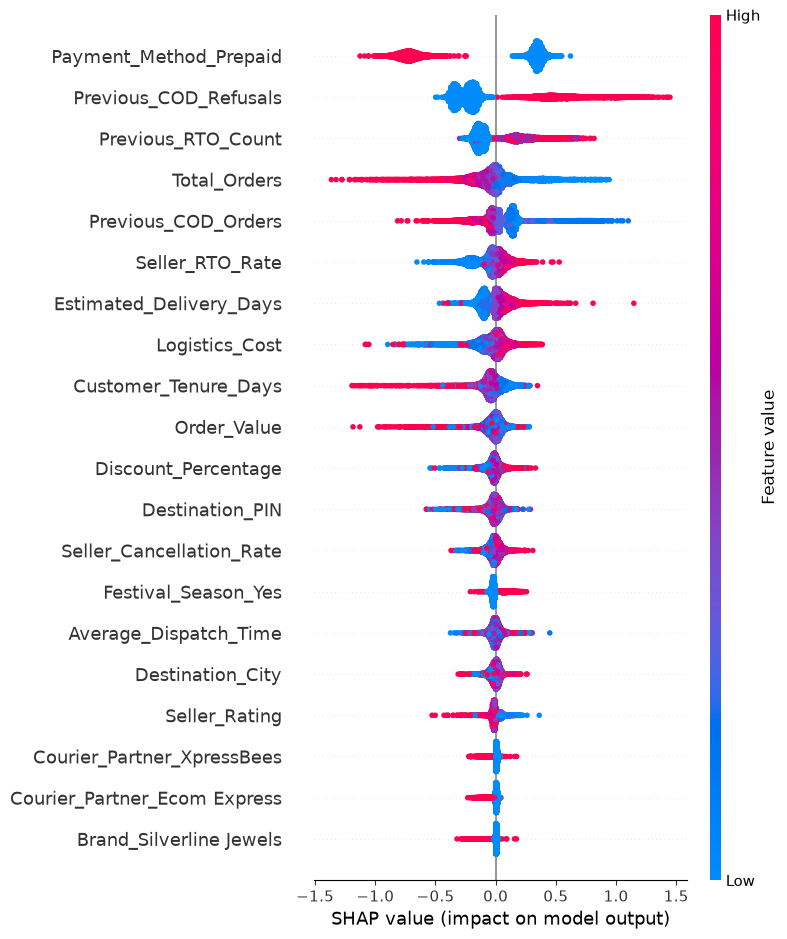

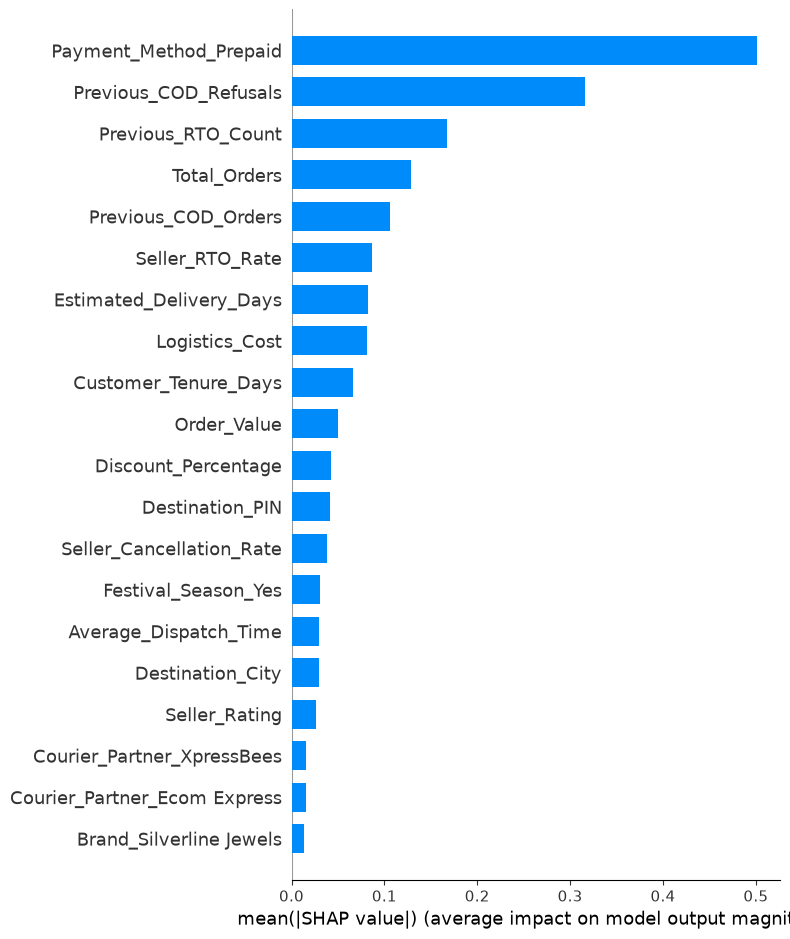

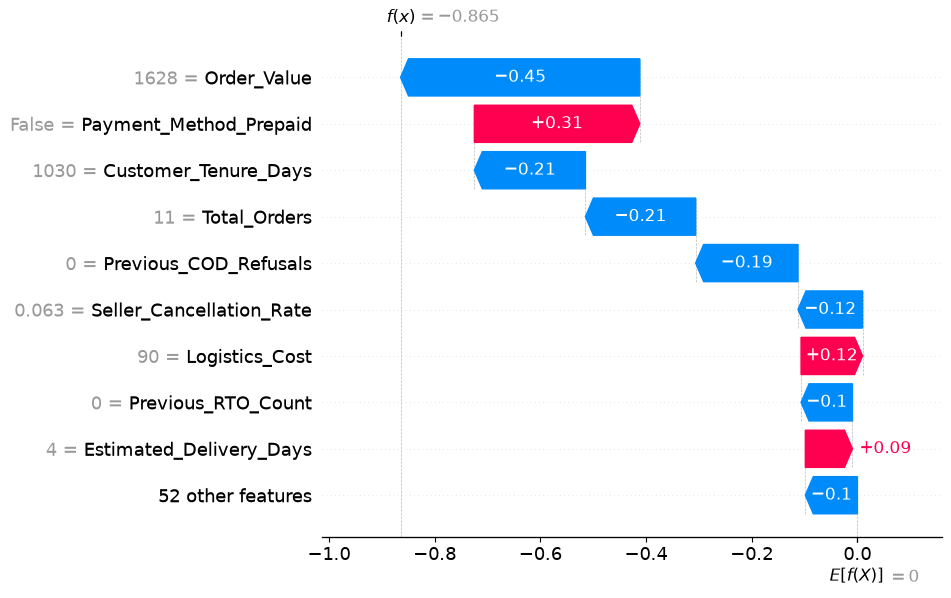

In [55]:
import shap
import joblib
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values,
    X_test
)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)
order_number = 5
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[order_number],
        base_values=explainer.expected_value,
        data=X_test.iloc[order_number],
        feature_names=X_test.columns
    )
)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

## Model Evaluation


The XGBoost model was evaluated using multiple metrics instead of relying solely on accuracy because the dataset is imbalanced.

The confusion matrix provides insight into correctly and incorrectly classified orders.

Precision measures how many predicted RTO orders were actually RTO.

Recall measures how many actual RTO orders were correctly identified.

The F1-score balances Precision and Recall.

ROC-AUC evaluates the model's ability to distinguish between RTO and non-RTO orders across different thresholds.

Feature importance analysis identifies the variables that contribute most to the model's predictions, helping operations teams understand which business factors influence RTO risk.

## Business Insight

The dataset is imbalanced, with successful deliveries significantly outnumbering RTO orders. Therefore, model evaluation should not rely only on accuracy. Metrics such as Precision, Recall, F1-score, and ROC-AUC will provide a more reliable assessment of model performance.

